<a href="https://colab.research.google.com/github/aannddrree/turmauniaraIA2/blob/main/introducao_python_ia_mestrado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução prática a Python para IA (Mestrado em Engenharia de Produção)
*Aula criada em:* **11/10/2025 09:38**

Este notebook cobre:
- Sintaxe básica do Python (variáveis, tipos, estruturas de controle, funções)
- Leitura e escrita de arquivos (TXT, CSV, JSON)
- Análise simples com `pandas` e gráfico com `matplotlib`
- Template para chamada de API de LLM (com **mock offline**, para não depender de internet)

**Dica ao professor(a):** execute célula a célula, explique o *porquê* de cada construção, e proponha pequenos exercícios ao final de cada seção.

## 0) Ambiente e preparação

In [1]:
# (Opcional) Verificando versão do Python e instalando pacotes essenciais
import sys
print('Versão do Python:', sys.version)

try:
    import pandas as pd
    import matplotlib.pyplot as plt
except ImportError:
    # Dica: em ambientes com internet, rode: !pip install pandas matplotlib
    print('Se necessário, instale: pandas e matplotlib')

Versão do Python: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]


## 1) Fundamentos da linguagem

In [2]:
# Variáveis e tipos
a = 10               # int
b = 3.14             # float
c = 'IA em Produção' # str
d = True             # bool
e = None             # NoneType
print(type(a), type(b), type(c), type(d), type(e))

# Conversões de tipo
print(int(b), float(a), str(a))

<class 'int'> <class 'float'> <class 'str'> <class 'bool'> <class 'NoneType'>
3 10.0 10


In [3]:
# Coleções: list, tuple, set, dict
lista = [1, 2, 3, 3]
tupla = (1, 2, 3)
conjunto = {1, 2, 3, 3}
dicionario = {'curso': 'IA', 'nivel': 'mestrado', 'carga_h': 4}
print('lista:', lista)
print('tupla:', tupla)
print('conjunto (sem duplicatas):', conjunto)
print('dicionario:', dicionario)

# Acesso e operações
lista.append(4)
dicionario['professor'] = 'André'
print(lista, dicionario)

lista: [1, 2, 3, 3]
tupla: (1, 2, 3)
conjunto (sem duplicatas): {1, 2, 3}
dicionario: {'curso': 'IA', 'nivel': 'mestrado', 'carga_h': 4}
[1, 2, 3, 3, 4] {'curso': 'IA', 'nivel': 'mestrado', 'carga_h': 4, 'professor': 'André'}


In [4]:
# Controle de fluxo: if/elif/else
nota = 7.8
if nota >= 9:
    conceito = 'A'
elif nota >= 7:
    conceito = 'B'
else:
    conceito = 'C'
print('Conceito:', conceito)

Conceito: B


In [5]:
# Laços: for e while
soma = 0
for i in range(5):
    soma += i
print('Soma 0..4 =', soma)

contador = 3
while contador > 0:
    print('Contagem:', contador)
    contador -= 1

Soma 0..4 = 10
Contagem: 3
Contagem: 2
Contagem: 1


In [6]:
# Funções e docstrings
def eficiencia_producao(unidades_produzidas: int, horas: float) -> float:
    """Retorna unidades por hora (UPH)."""
    if horas <= 0:
        raise ValueError('Horas deve ser > 0')
    return unidades_produzidas / horas

print('UPH =', eficiencia_producao(500, 7.5))

UPH = 66.66666666666667


### Exercícios rápidos (turma)

1. Crie uma função `custo_unitario(total, quantidade)` que retorne o custo por unidade.
2. Dada uma lista de tempos (em minutos) para concluir tarefas, calcule média e desvio padrão **sem usar pandas**.
3. Dada uma lista de defeitos por lote, conte a frequência (use `dict` ou `collections.Counter`).

## 2) Arquivos: TXT, CSV e JSON

In [7]:
# Escrever e ler TXT
conteudo = 'Relatório de produção\nLotes OK: 125\nLotes com retrabalho: 7\n'
with open('relatorio.txt', 'w', encoding='utf-8') as f:
    f.write(conteudo)
print('Arquivo TXT gravado.')

with open('relatorio.txt', 'r', encoding='utf-8') as f:
    print('Conteúdo lido:')
    print(f.read())

Arquivo TXT gravado.
Conteúdo lido:
Relatório de produção
Lotes OK: 125
Lotes com retrabalho: 7



In [8]:
# CSV com dados de exemplo
import csv
linhas = [
    ['lote','tempo_min','defeitos'],
    ['A', 42, 0],
    ['B', 37, 1],
    ['C', 55, 2],
    ['D', 29, 0],
]
with open('producao.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerows(linhas)
print('CSV gravado (producao.csv).')

# Leitura com csv
with open('producao.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    for row in reader:
        print(row)

CSV gravado (producao.csv).
['lote', 'tempo_min', 'defeitos']
['A', '42', '0']
['B', '37', '1']
['C', '55', '2']
['D', '29', '0']


In [18]:
import json

# JSON (útil para APIs)
dados = {
    'data': '2025-10-11',
    'turno': 'noturno',
    'itens': [
        {'lote': 'A', 'tempo_min': 42, 'defeitos': 0},
        {'lote': 'B', 'tempo_min': 37, 'defeitos': 1}
    ]
}
with open('dados.json', 'w', encoding='utf-8') as f:
    json.dump(dados, f, ensure_ascii=False, indent=2)
print('JSON gravado (dados.json).')

with open('dados.json', 'r', encoding='utf-8') as f:
    print(f.read())

JSON gravado (dados.json).
{
  "data": "2025-10-11",
  "turno": "noturno",
  "itens": [
    {
      "lote": "A",
      "tempo_min": 42,
      "defeitos": 0
    },
    {
      "lote": "B",
      "tempo_min": 37,
      "defeitos": 1
    }
  ]
}


## 3) Mini-análise com `pandas` e gráfico com `matplotlib`

,lote,tempo_min,defeitos
0,A,42,0
1,B,37,1
2,C,55,2
3,D,29,0


Tempo médio (min): 40.75
Total de defeitos: 3


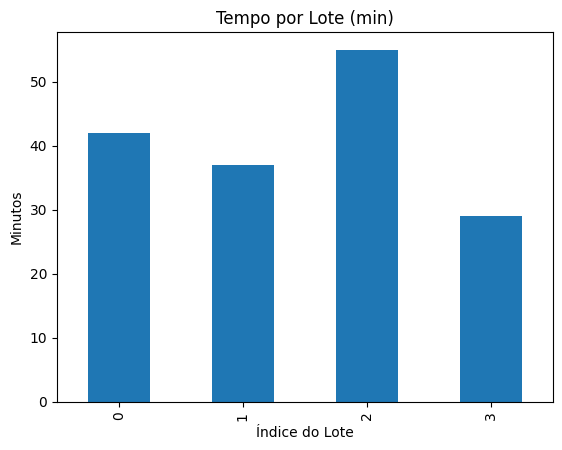

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('producao.csv')
display(df)

# Estatísticas simples
print('Tempo médio (min):', df['tempo_min'].mean())
print('Total de defeitos:', df['defeitos'].sum())

# Gráfico simples (um gráfico por figura; sem definir cores explicitamente)
plt.figure()
df['tempo_min'].plot(kind='bar', title='Tempo por Lote (min)')
plt.xlabel('Índice do Lote')
plt.ylabel('Minutos')
plt.show()

## 4) Boas práticas rápidas: exceções, *context managers*, *typing*

In [12]:
from typing import List

def media_segura(valores: List[float]) -> float:
    try:
        return sum(valores) / len(valores)
    except ZeroDivisionError:
        return float('nan')

print(media_segura([1, 2, 3]))
print(media_segura([]))

2.0
nan


## 5) Template para chamada de API de LLM (com mock offline)
A seguir há dois exemplos:
1. **Mock offline:** simula uma chamada a um provedor de LLM, sem internet.
2. **Template real (comentado):** mostra como seria com bibliotecas de provedores (substitua a chave e descomente em um ambiente com internet).

In [13]:
# 5.1) Mock offline de uma chamada a LLM
def chamar_llm_mock(prompt: str) -> str:
    """
    Simula uma resposta de um LLM, útil para testes offline em sala.
    """
    return f"[MOCK-LLM] Você perguntou: '{prompt}'. Resposta simulada para fins didáticos."

pergunta = 'Explique rapidamente o que é aprendizado supervisionado.'
print(chamar_llm_mock(pergunta))

[MOCK-LLM] Você perguntou: 'Explique rapidamente o que é aprendizado supervisionado.'. Resposta simulada para fins didáticos.


In [14]:
# 5.2) Template real com OpenAI (exemplo) — **comentado**
## Instale e configure em ambiente com internet:
## pip install openai
## export OPENAI_API_KEY='sua_chave_aqui'
##
## from openai import OpenAI
## client = OpenAI()  # usa OPENAI_API_KEY do ambiente
## resp = client.chat.completions.create(
##     model='gpt-4o-mini',
##     messages=[{'role': 'user', 'content': 'Explique KNN em 3 frases'}]
## )
## print(resp.choices[0].message.content)

In [15]:
# 5.3) Template real com Google (Gemini) — **comentado**
## pip install google-generativeai
## import google.generativeai as genai
## genai.configure(api_key='SUA_CHAVE')
## model = genai.GenerativeModel('gemini-1.5-flash')
## resp = model.generate_content('Explique o teorema de Bayes em linguagem simples')
## print(resp.text)

### Exercícios (LLM/API)
- Adaptar o `chamar_llm_mock` para devolver também **citações** (lista de strings) junto com o texto.
- (Em ambiente com internet) Trocar o *prompt* para gerar **pseudocódigo** de um algoritmo de inspeção de qualidade.
- Criar uma função que recebe uma lista de *prompts* e retorna as respostas (mock), mantendo a ordem.

## 6) Mini-projeto guiado (20–30 min)
**Objetivo:** ler `producao.csv`, calcular KPIs simples e salvar um relatório em `relatorio_final.txt`.

**Passos:**
1. Ler `producao.csv` com `pandas`.
2. Calcular: tempo médio, tempo máximo, % de lotes com defeito > 0.
3. Gerar um gráfico de barras do tempo por lote.
4. Escrever tudo (textualmente) em `relatorio_final.txt`.
5. (Opcional) Chamar o `chamar_llm_mock` para sintetizar os resultados em 2–3 frases.


Relatório e gráfico gerados.


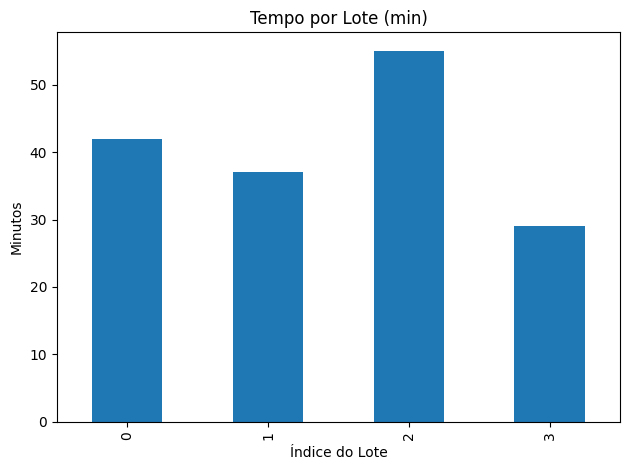

In [16]:
# Gabarito sugerido (professor pode esconder/mostrar)
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('producao.csv')
tempo_medio = df['tempo_min'].mean()
tempo_max = df['tempo_min'].max()
pct_defeito = (df['defeitos'] > 0).mean() * 100
plt.figure()
df['tempo_min'].plot(kind='bar', title='Tempo por Lote (min)')
plt.xlabel('Índice do Lote')
plt.ylabel('Minutos')
plt.tight_layout()
plt.savefig('grafico_lotes.png')
with open('relatorio_final.txt', 'w', encoding='utf-8') as f:
    f.write('RELATÓRIO FINAL\n')
    f.write(f'Tempo médio: {tempo_medio:.2f} min\n')
    f.write(f'Tempo máx.: {tempo_max:.2f} min\n')
    f.write(f'% lotes com defeito: {pct_defeito:.1f}%\n')
    f.write('Gráfico salvo em grafico_lotes.png\n')
print('Relatório e gráfico gerados.')

## 7) Referências rápidas
- Tutorial oficial Python: https://docs.python.org/pt-br/3/tutorial/
- Pandas: https://pandas.pydata.org/docs/
- Matplotlib: https://matplotlib.org/stable/
- PEP 8 (estilo): https://peps.python.org/pep-0008/
- OpenAI Python: https://platform.openai.com/docs
- Google Gemini (Generative AI): https://ai.google.dev
